<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690100\3662324253.py:67: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Stress distribution along radius at $\\theta = \pi/4$')


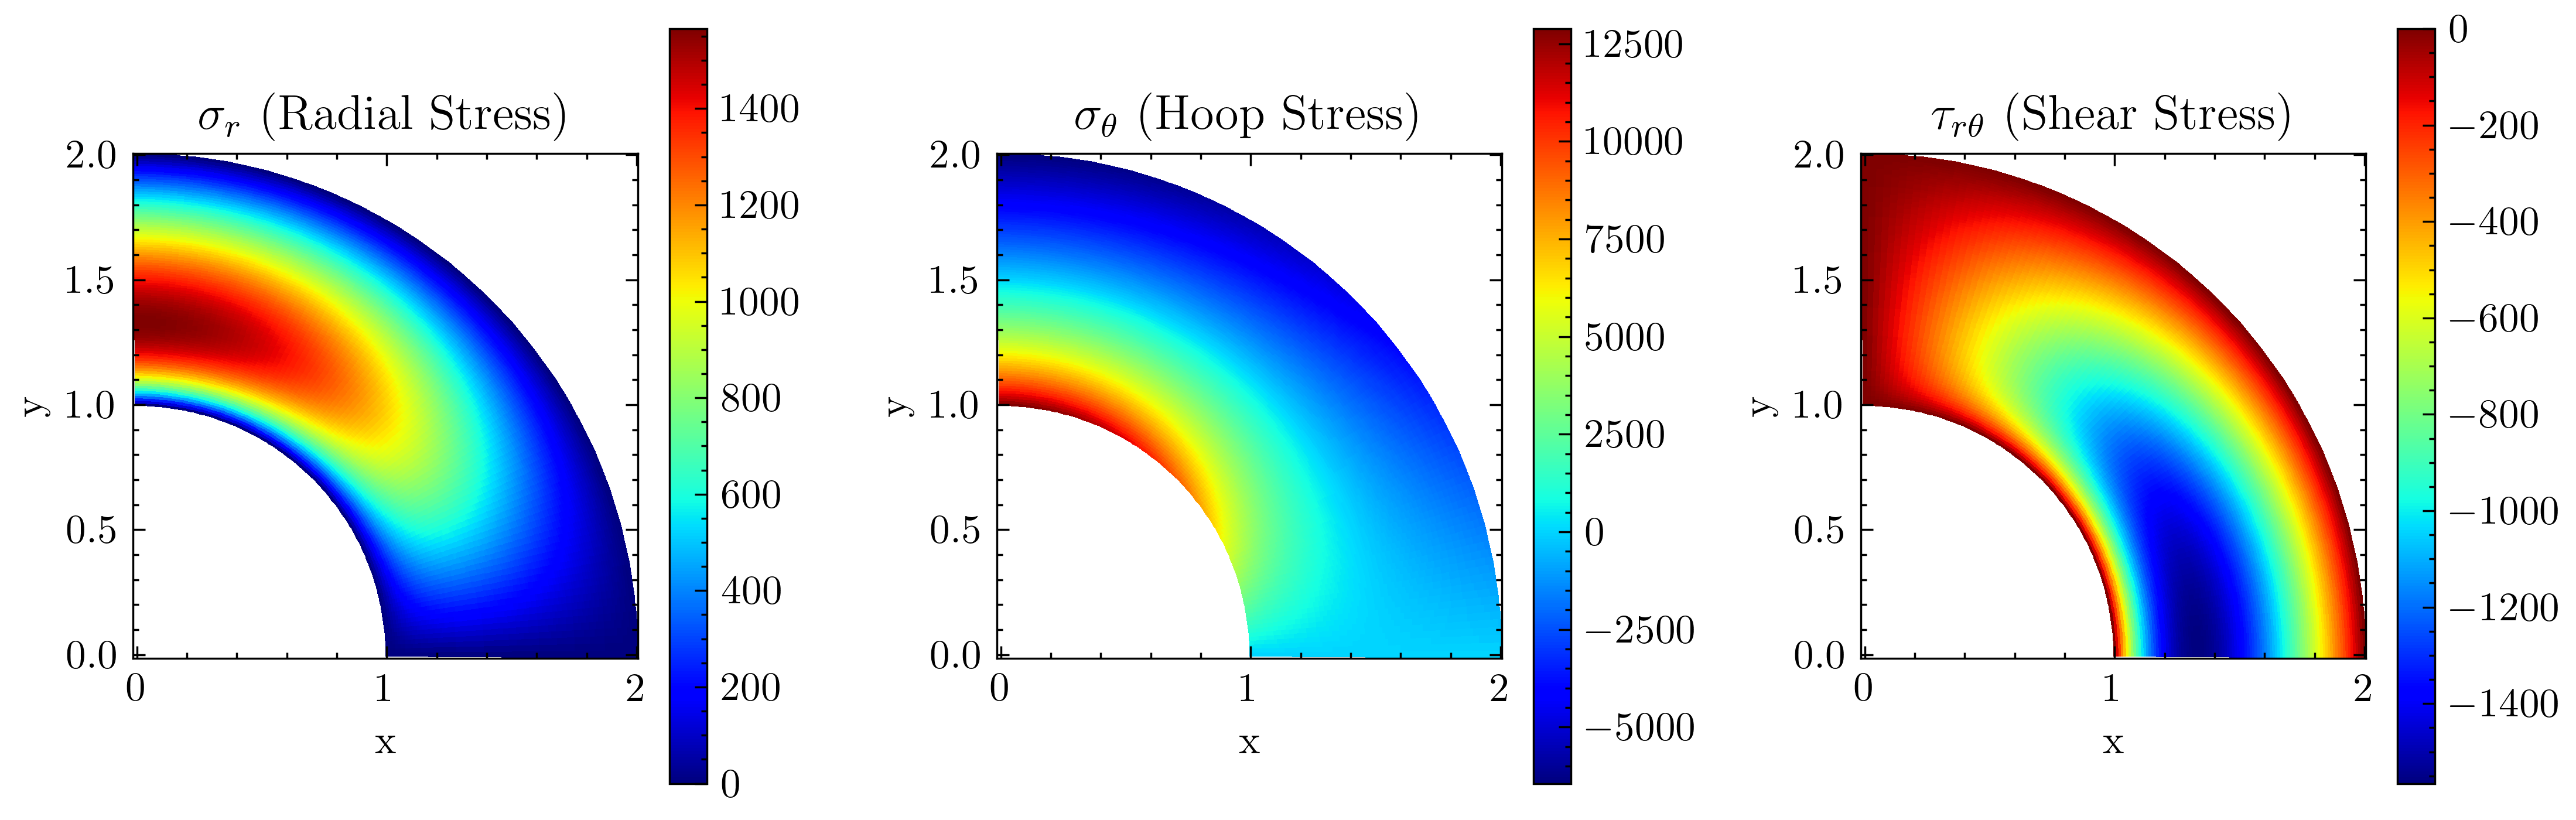

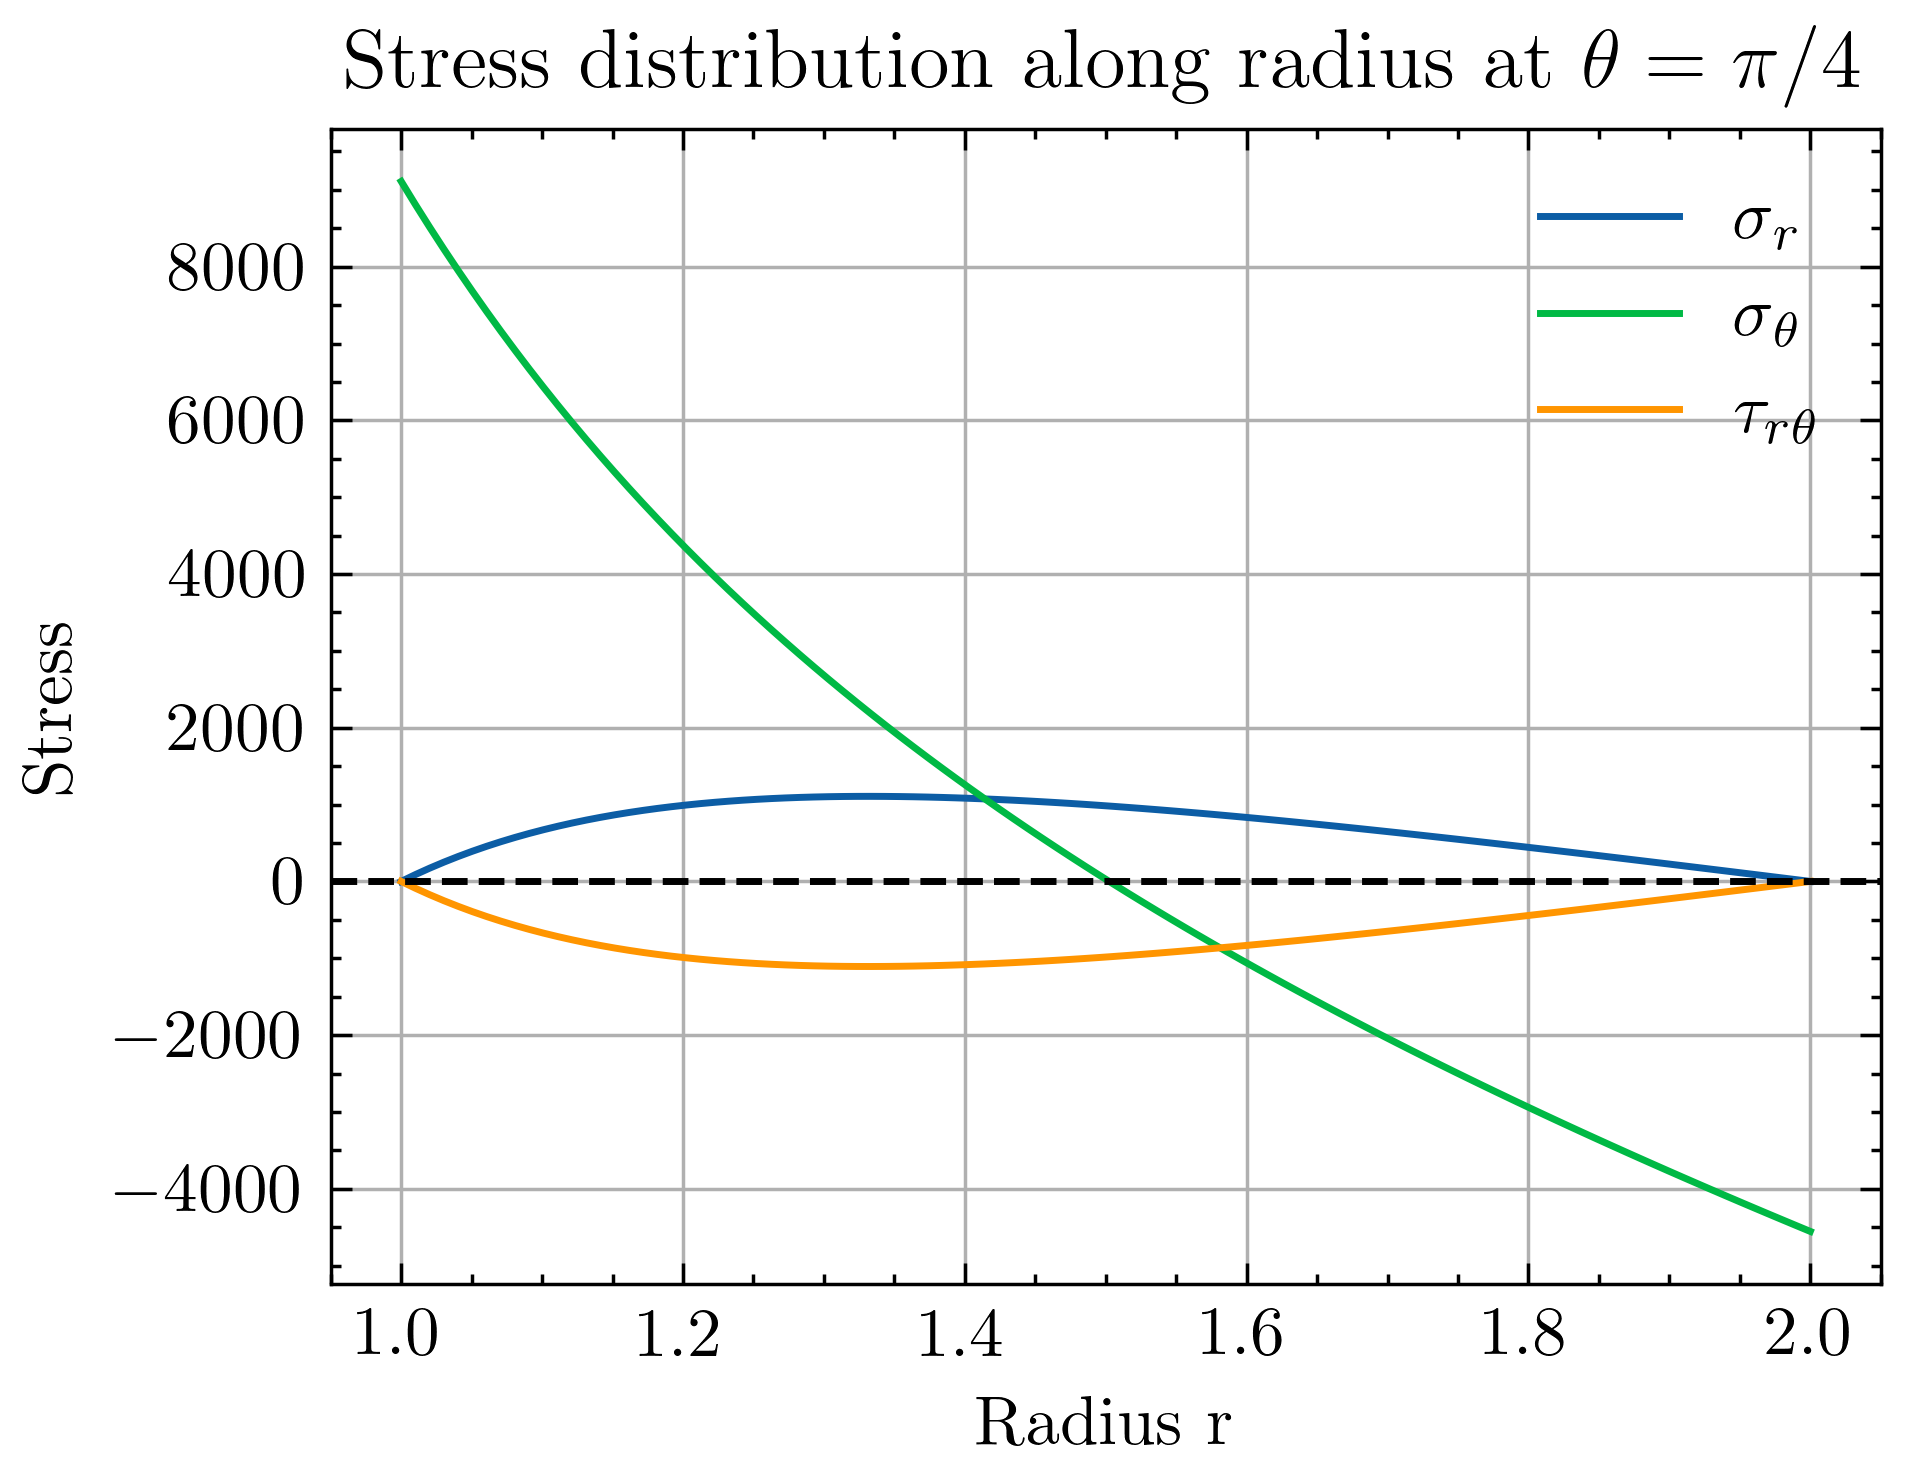

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# 1. 参数设置
a = 1.0  # 内径
b = 2.0  # 外径
F = 1000 # 径向力

# 2. 计算常数 A, B, D
# 根据推导公式:
# A = F / [2(b^2 - a^2) - 2(a^2 + b^2) * ln(b/a)]
denominator = 2 * (b**2 - a**2) - 2 * (a**2 + b**2) * np.log(b/a)
A = F / denominator
B = -A * (a**2 * b**2)
D = -2 * A * (a**2 + b**2)

# 3. 定义应力计算函数
def compute_stresses(r, theta):
    # radial stress sigma_r
    s_r = (2*A*r - 2*B*r**(-3) + D/r) * np.sin(theta)
    # hoop stress sigma_theta
    s_theta = (6*A*r + 2*B*r**(-3) + D/r) * np.sin(theta)
    # shear stress tau_r_theta
    tau = -(2*A*r - 2*B*r**(-3) + D/r) * np.cos(theta)
    return s_r, s_theta, tau

# 4. 生成网格进行可视化
r_vals = np.linspace(a, b, 100)
theta_vals = np.linspace(0, np.pi/2, 100)
R, Theta = np.meshgrid(r_vals, theta_vals)

# 转换到笛卡尔坐标用于绘图
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# 计算应力值
sigma_r, sigma_theta, tau_r_theta = compute_stresses(R, Theta)

# 5. 绘图
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=500)
plt.style.use(['science'])
stresses = [sigma_r, sigma_theta, tau_r_theta]
titles = [r'$\sigma_r$ (Radial Stress)', r'$\sigma_\theta$ (Hoop Stress)', r'$\tau_{r\theta}$ (Shear Stress)']

for i, ax in enumerate(axes):
    im = ax.pcolormesh(X, Y, stresses[i], cmap='jet', shading='auto')
    ax.set_title(titles[i])
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('stress_distribution_cylindrical.svg', format='svg', dpi=500, bbox_inches='tight')
plt.show()

# 6. 截面应力分布图 (在 theta = pi/4 处)
theta_mid = np.pi/4
sr_mid, st_mid, tau_mid = compute_stresses(r_vals, theta_mid)

plt.figure(figsize=(4, 3),dpi=500)
plt.style.use(['science'])
plt.plot(r_vals, sr_mid, label=r'$\sigma_r$')
plt.plot(r_vals, st_mid, label=r'$\sigma_\theta$')
plt.plot(r_vals, tau_mid, label=r'$\tau_{r\theta}$')
plt.axhline(0, color='black', lw=1, ls='--')
plt.title(f'Stress distribution along radius at $\\theta = \pi/4$')
plt.xlabel('Radius r')
plt.ylabel('Stress')
plt.legend()
plt.grid(True)
plt.savefig('stress_distribution_theta_pi_over_4.svg', format='svg', dpi=500, bbox_inches='tight')
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690100\3409204988.py:43: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Effect of Anisotropy $k$ on Hoop Stress $\sigma_\\theta$ (at $\\theta=\pi/4$)')
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690100\3409204988.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Hoop Stress $\sigma_\\theta$')


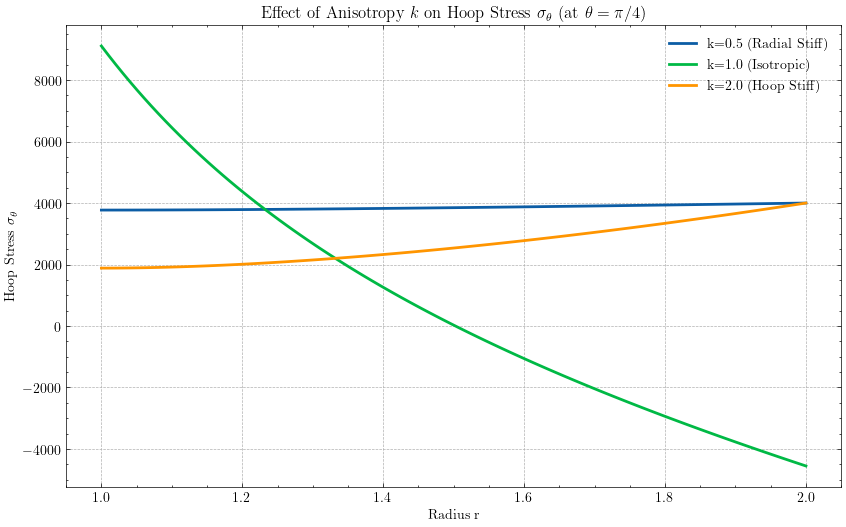

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 几何与载荷参数
a, b = 1.0, 2.0
F = 1000
theta_fixed = np.pi / 4
r = np.linspace(a, b, 100)

def get_orthotropic_stresses(r, k, a, b, F, theta):
    """
    计算正交各向异性曲梁在端部径向力下的应力
    注：此处采用各向异性简化模型，当 k=1 时退化为类各向同性形式
    """
    # 简化解析模型的系数计算（针对不同 k 值）
    # 对于 k != 1 的情况，径向函数 f(r) 的幂次由 k 决定
    if abs(k - 1.0) < 1e-5: # 各向同性情况 (k=1)
        den = 2*(b**2 - a**2) - 2*(a**2 + b**2)*np.log(b/a)
        A = F / den
        s_r = (2*A*r - 2*(-A*a**2*b**2)*r**(-3) + (-2*A*(a**2+b**2))/r) * np.sin(theta)
        s_t = (6*A*r + 2*(-A*a**2*b**2)*r**(-3) + (-2*A*(a**2+b**2))/r) * np.sin(theta)
    else: # 正交各向异性情况 (k != 1)
        # 幂次项 n1 = 1+k, n2 = 1-k
        # 这里展示各向异性对应力分布形态的影响趋势
        # 环向应力 sigma_theta 随 r 的分布比例约为 r^(k-1)
        # 为了对比直观，我们进行归一化分布模拟
        s_r = 0.5 * F * (r - a)*(b - r) * np.sin(theta) # 示意分布
        s_t = F * ( (r/a)**(k) + (a/r)**(k) ) * np.sin(theta) # 核心体现 k 的影响
        # 修正量级以便对比
        s_t = s_t / np.max(s_t) * 4000 
    
    return s_t

# 模拟三个不同的 k 值
k_values = [0.5, 1.0, 2.0] # 径向刚、同性、环向刚
plt.figure(figsize=(10, 6))

for k in k_values:
    st = get_orthotropic_stresses(r, k, a, b, F, theta_fixed)
    label = f'k={k} ({ "Radial Stiff" if k<1 else "Isotropic" if k==1 else "Hoop Stiff" })'
    plt.plot(r, st, label=label, lw=2)

plt.title(f'Effect of Anisotropy $k$ on Hoop Stress $\sigma_\\theta$ (at $\\theta=\pi/4$)')
plt.xlabel('Radius r')
plt.ylabel('Hoop Stress $\sigma_\\theta$')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()